# <b>Dimensionality Reduction Project</b>

This project notebook focuses on <b>dimensionality reduction</b>.

More precisely, we will first load our dataset to work with, MNIST, and then implement and run the dataset on the two algorithms

- <b>Principal Component Analysis (PCA)</b> and
- <b>Stochastic Neighbor Embedding (SNA)</b>.


Lastly, we will also test a more modern version, t-SNE, on our dataset and compare the results.

## 0. Preparing the notebook
Before we can begin, we need to prepare the notebook by importing any libraries we will use.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Loading the data

Our first step is to load our set of data we will work with.

<b>MNIST</b> is a set of 60.000 greyscale, 28×28 pixel images depicting handwritten digits.<br>
We will take a random subset of 6.000 images.

### 1.1 Loading the data

In [2]:
from sklearn.datasets import fetch_openml

data, labels = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)


### 1.2 Getting a random subset from the dataset

In [3]:
samples = 6000

indices = np.random.choice(data.shape[0], size=samples, replace=False)

X = data[indices]
sub_labels = labels[indices]


## 2. Principal Component Analysis (PCA)

Next, we will first implement the <b>PCA algorithm</b> and apply it to our subset of data.

PCA is a method for linear dimensionality reduction.<br>
It finds a linear projection of the provided data and projects its new dimensions uncorrelated and sorted by variance.<br>
The dimensionality gets reduced by discarding points of smaller variance.

### 2.1 Centering the data
For our set of data, represented as matrix $X$, we first produce the <b>centered matrix $\hat{X}$</b> so that the mean is zero across all data points.

In [4]:
X_hat = X - np.mean(X, axis=0)

### 2.2 Calculating the covariance
We calculate the <b>covariance matrix $C$</b> of $\hat{X}$ like follows:
$$C = \hat{X}^{T} \hat{X}$$

In [5]:

C = np.matmul(X_hat.T, X_hat)


### 2.3 Calculating eigenvectors and corresponding eigenvalues
Here, we calculate the eigenvectors $V = \{v_{i}\}_{i=1, ..., 784}$ and their eigenvalues $\{w_{i}\}_{i=1, ..., 784}$ of $C$.

In [6]:
w, V = np.linalg.eig(C)

### 2.4 Projecting data onto eigenvectors

Now, we will project our data onto the eigenvectors $V$, i.e., we are aligning the points along new axes. We compute the aligned data $Z$ as
$$V = \hat{X}V$$

In [7]:
Z = np.matmul(X_hat, V)

### 2.5 Scaling the projected data
As a last step of the algorithm, we <b>scale</b> the projected data and thus normalize their spread.<br>
The scaled projected data $\hat{Z}$ is calculated by dividing each dimension with the square root of its corresponding eigenvalue.

In [8]:
# Adding a very small value 1e-5 to avoid Run time Warning
# and casting Z_hat to datatype 'real' to avoid Complex Warning
Z_hat = np.real(Z / (np.sqrt(w) + 1e-5))

### 2.6 Plotting the result
Finally, we will plot our result.

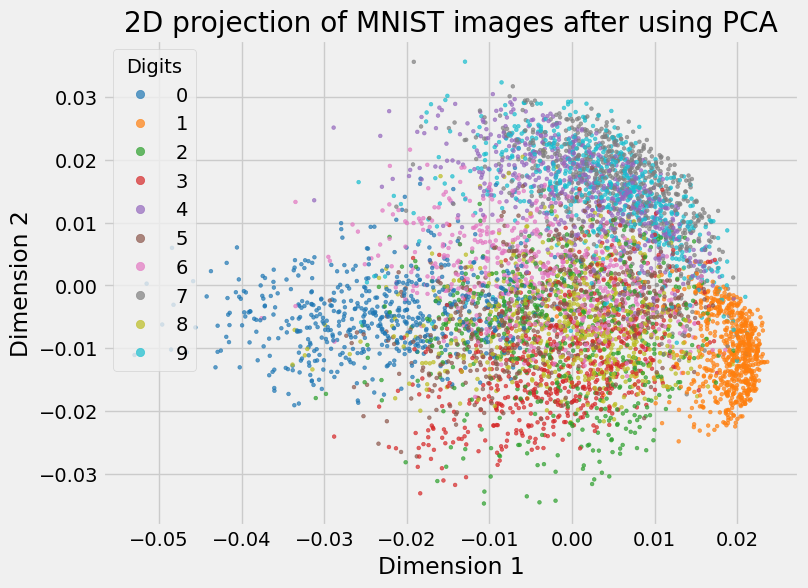

In [9]:
# Casting the labels from strings to integers to color the plot for each digit
sub_labels = sub_labels.astype(int)

with plt.style.context('fivethirtyeight'):

    plt.figure(figsize=(8,6))
    scatter = plt.scatter(Z_hat[:, 0], Z_hat[:, 1], c=sub_labels, cmap='tab10', s=7, alpha=0.7)

    colors, pltlabels = scatter.legend_elements()
    plt.legend(colors, pltlabels, title='Digits')

    plt.title('2D projection of MNIST images after using PCA')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    
    plt.show()

The resulting plot shows the two dimensions with the largest variance.

It looks quite like what we expected, given that the plots in Figure 1.1 in the
Dimensionality Reduction project brief and our own plot above look similar.<br>
In our plot, it looks like the points are slightly less clustered.


## 2.7 Anohter method (sklearn)


In [10]:

import sklearn as sl

pca = sl.decomposition.PCA(n_components=2) 
# here i decide to take the first two main components 


In [11]:
X.T.shape

(784, 6000)

In [12]:

# Run PCA

pca.fit(X_hat.T) # should take the first two dimensions and take the centered data 

# Get first component

pc1 = pca.components_[0]
pc2 = pca.components_[1]

print(f'The first two components shape is : ', pca.components_.shape)


The first two components shape is :  (2, 6000)


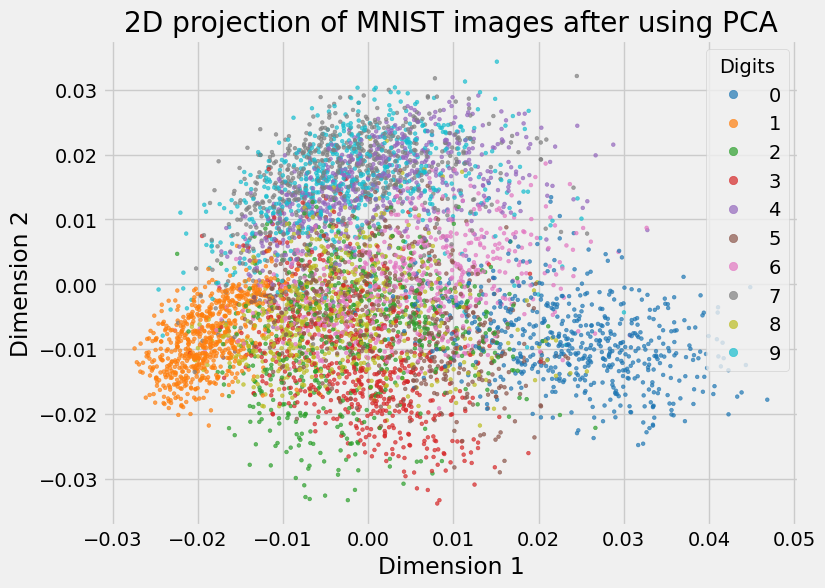

In [13]:

with plt.style.context('fivethirtyeight'):

    plt.figure(figsize=(8,6))
    scatter = plt.scatter(pc1, pc2, c=sub_labels, cmap='tab10', s=7, alpha=0.7)

    colors, pltlabels = scatter.legend_elements()
    plt.legend(colors, pltlabels, title='Digits')

    plt.title('2D projection of MNIST images after using PCA')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    
    plt.show()


## 3. Stochastic Neighbour Embedding
Now, we will implement the <b>SNE algorithm</b> and use it on our subset of data.

SNE, unlike PCA, is a non-linear technique for dimensionality reduction.<br>
It takes the neighbourhood structure of data into account by calculating the probabilities of points being neighbours<br>
and reflects that onto low dimensional points.

### 3.1 Distances and probability function
First, we will create a function which calculates the <b>squared and scaled distance</b>
$$d_{ij} = \frac{||x_{i} - x_{j}||^{2}}{2\sigma^{2}} = \frac{||x_{i}||^{2} + ||x_{j}||^{2} - 2x_{i}\cdot x_{j}}{2\sigma^{2}}$$
and then compute the <b>probability</b>
$$p_{ij} = \frac{\exp(-d_{ij})}{\sum_{k\neq j} \exp(-d_{ik})}$$
for each pair of data points $x_{i}, x_{j}$.

The function will return <b>matrix d</b> of all distances and the <b>probability matrix P</b>.

In [14]:
def distance_probability(matrix, sigma):
    '''
    Calculates the squared and scaled euclidean distances d and probability P.

    Arguments:
    matrix: Matrix of data points to operate on.
    sigma: Scaling factor.

    Returns:
    d: Distances of all pairs of data points
    P: Matrix of probabilities that two data points are close to each other
    '''
    sqrd_sum = np.sum(np.square(matrix), axis=1, keepdims=True)
    sqrd_dist = sqrd_sum + sqrd_sum.T - 2 * np.matmul(matrix, matrix.T)

    d = sqrd_dist / (2.0 * np.square(sigma))

    d_exp = np.exp(-d)
    # Setting all points d_ii to zero to avoid these dominating the probabilities
    np.fill_diagonal(d_exp, 0)

    d_sum = np.sum(d_exp, axis=1, keepdims=True)
    
    P = d_exp / d_sum


    return d, P

### 3.2 Loss function
Next, we implement a function to calculate the <b>loss</b>. Our loss function expresses the divergence (so the opposite of similarity) of P and Q,
<br>which is calculated as the <b>Kullback-Leibler Divergence</b>:
$$D_{KL}(P||Q) = \sum_{i}\sum_{j} p_{ij}\log{}(\frac{p_{ij}}{q_{ij}})$$

In [15]:
# Loss function
def loss(P, Q):
    '''
    Calculates the loss of P and Q, being the Kullback-Leibler Divergence.

    Arguments:
    P: Probability matrix of high dimensional data points.
    Q: Probability matrix of low dimensional data points.

    Returns:
    KL: The Kullback-Leibler Divergence between P and Q.
    '''

    # Adding a very small value to avoid dividing 0 and dividing by 0
    KL = np.sum(P * np.log((P + 1e-12) / (Q + 1e-12)))
    
    return KL

### 3.3 Gradient function
Now, we will implement a function which calculates the <b>gradient</b>
$$g(z_{i}) = \frac{\delta D_{KL}(P||Q)}{\delta z_{i}} = 2 \sum_{j} (z_{i} - z_{j})(p_{ij} + p_{ji} - q_{ij} - q_{ji}).$$

In [16]:
# Gradient function
def gradient(Z, P, Q):
    '''
    Calculates the gradient.

    Arguments:
    Z: Matrix of low dimensional data points.
    P: Probability matrix of high dimensional dataset.
    Q: Probability matrix of low dimensional dataset Z.

    Returns:
    g: Gradient
    '''
    vector = Z[:, np.newaxis, :] - Z[np.newaxis, :, :]

    scalar = (P + P.T - Q - Q.T)
    
    g = 2 * np.sum(vector * scalar[:, :, np.newaxis], axis=1)

    
    return g

### 3.4 Creating low dimensional data points
In this step, we will create a <b>two dimensional dataset $Z$</b>.
The dataset will have random data points from a Gaussian distribution with $\mu = 0$ and $\sigma = 0.1$.

In [17]:
mu = 0
sigma = 0.1
# samples = 6000 was already defined above

z = np.random.normal(loc=mu, scale=sigma, size=(samples, 2))

### 3.5 Gradient descent
Now, we will repeatedly use gradient descent on our two dimensional dataset z until it converges.

For this, we will implement a class <b>Adam</b> which uses the Adam optimizer.

In [18]:
class Adam:
    def __init__(self, beta_1=0.9, beta_2=0.999, epsilon=10**-8, step_size=0.1):
        '''
        Initializes a new instance of the Adam optimizer.
        '''
        self.beta_1 = beta_1
        self.beta_2 = beta_2
        self.epsilon = epsilon
        self.step_size = step_size
        
        self.m, self.v = 0, 0    # m and v are initialized with 0 by default and shouldn't be changed
        self.t = 1

        
    def optimize(self, dataset, gradient):
        '''
        Method that repositions data points of the given dataset.
        '''
        self.m = self.beta_1 * self.m + (1 - self.beta_1) * gradient
        self.v = self.beta_2 * self.v + (1 - self.beta_2) * np.power(gradient, 2)

        m_hat = self.m / (1 - np.power(self.beta_1, self.t))
        v_hat = self.v / (1 - np.power(self.beta_2, self.t))

        dataset = dataset - self.step_size * m_hat / (np.sqrt(v_hat) + self.epsilon)

        self.t += 1

        
        return dataset

In [19]:
adam = Adam(step_size=0.3)

iterations = 50

d_x, P = distance_probability(X, 1000)
d_z, Q = distance_probability(z, 1)

for t in range(iterations):
    
    grad = gradient(z, P, Q)

    z = adam.optimize(z, grad)

    d_z, Q = distance_probability(z, 1)

    curr_loss = loss(P, Q)
    print("Loss after iteration " + str(t+1) + ": " + str(curr_loss))

Loss after iteration 1: 1763.812055430134
Loss after iteration 2: 1665.0486461908429
Loss after iteration 3: 1656.7497510425267
Loss after iteration 4: 1652.3769440572107
Loss after iteration 5: 1593.8897998848724
Loss after iteration 6: 1514.2610176650405
Loss after iteration 7: 1440.7003509400984
Loss after iteration 8: 1384.7235910074305
Loss after iteration 9: 1340.930589325174
Loss after iteration 10: 1301.8191607265173
Loss after iteration 11: 1269.9664806641927
Loss after iteration 12: 1246.6325289738709
Loss after iteration 13: 1228.5774932633012
Loss after iteration 14: 1213.6825775792518
Loss after iteration 15: 1201.9198090024652
Loss after iteration 16: 1191.9546891874047
Loss after iteration 17: 1181.8062626115477
Loss after iteration 18: 1170.5114219423804
Loss after iteration 19: 1158.2855031538702
Loss after iteration 20: 1146.00445056017
Loss after iteration 21: 1134.6145609462349
Loss after iteration 22: 1124.562439373938
Loss after iteration 23: 1115.9238741869872
Lo

### 3.6 Plotting the result
Finally, we will once again create a plot, this time for the result of our SNE algorithm.

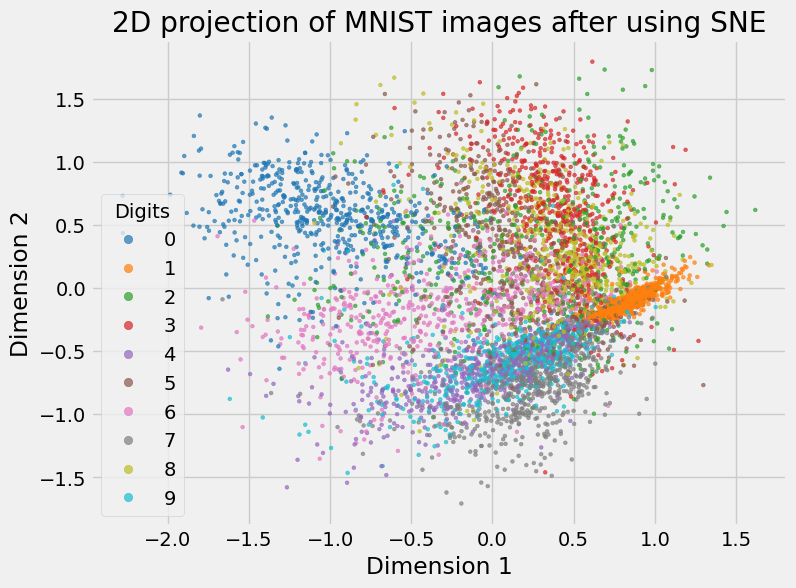

In [20]:
# Casting the labels from strings to integers was already done

with plt.style.context('fivethirtyeight'):

    plt.figure(figsize=(8,6))
    scatter = plt.scatter(z[:, 0], z[:, 1], c=sub_labels, cmap='tab10', s=7, alpha=0.7)

    colors, pltlabels = scatter.legend_elements()
    plt.legend(colors, pltlabels, title='Digits')

    plt.title('2D projection of MNIST images after using SNE')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    
    plt.show()

The plot is not as clustered as we might have expected. To achieve more clustering, we would have to run SNE on more iterations.<br>
Compared to the PCA plot, the plots look surprisinly similar. The SNE plot shows that the data points are slightly more clustered.

## 4. t-SNE
In the final section, we will import t-SNE from scikit-learn, run it on our data set and compare it with the result of our SNE algorithm from the section above.

First, we import scikit-learn.

In [21]:
import sklearn

In [22]:
dimensions = 2

tSNE = sklearn.manifold.TSNE(dimensions)
X_tSNE = tSNE.fit_transform(X)

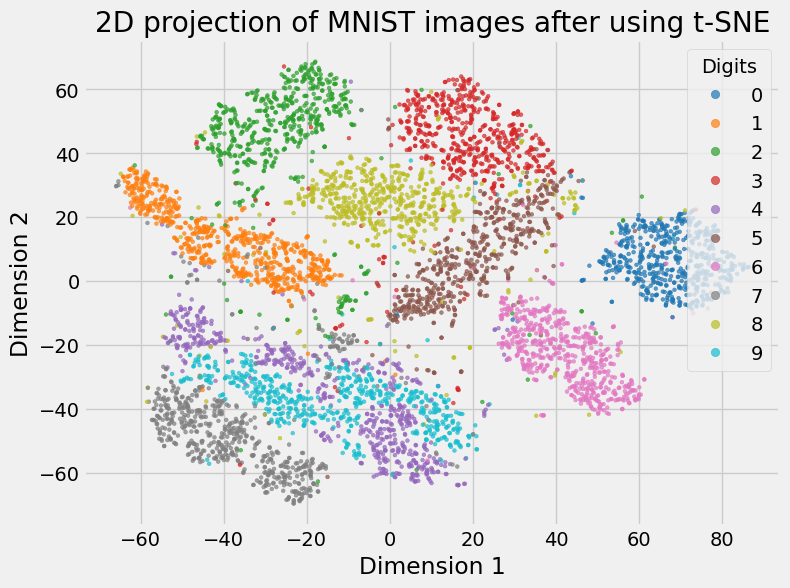

In [23]:
with plt.style.context('fivethirtyeight'):

    plt.figure(figsize=(8,6))
    scatter = plt.scatter(X_tSNE[:, 0], X_tSNE[:, 1], c=sub_labels, cmap='tab10', s=7, alpha=0.7)

    colors, pltlabels = scatter.legend_elements()
    plt.legend(colors, pltlabels, title='Digits')

    plt.title('2D projection of MNIST images after using t-SNE')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    
    plt.show()

The plot looks exactly how we excepted it.<br>
Compared to the SNE plot, you can clearly see the desired clustering in the t-SNE plot.